# Exam Project - Introduction to Social Data Science
August 28, 2024

## Project: Forecasting Vote Counts for Danish Borgerforslag

## Group 7:
- Oliver Nyrop Weeks (vsn684)
- Sofus Galavits Møller (qvc730)
- Victor V. Kristensen (gcp458)
- Jonas T. Schmidt (mcp656)

## Load modules

In [1]:
# Module Imports
import pandas as pd            # For data manipulation and analysis
from bs4 import BeautifulSoup  # For parsing HTML content
import time                    # For managing time delays during scraping
import tqdm                    # For displaying progress bars during scraping
import pprint                  # For neatly displaying JSON cod
import re                      # For pattern recognition in extracted HTML
import os                      # For interacting with the operating system (e.g., file paths, environment variables)

import matplotlib.pyplot as plt
import seaborn as sns

output_dir = "Output"

## Check dataset

In [2]:
# Load the dataset from the CSV file
loaded_df = pd.read_csv("data/df_after_categorization.csv")

# Display the first few rows of the loaded DataFrame
loaded_df

,Title,Start Date,Votes,Body Text,Num Coauthors,Days from start to scrape,Days from start to end,Lifetime,Month_2,Month_3,...,topic_1,topic_2,topic_3,topic_4,topic_5,topic_6,topic_7,topic_8,topic_9,topic_10
0,Afskaf inklusionsloven,2024-08-15,39,For at forbedre undervisningen og sikre optima...,3,3,180,3,False,False,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0
1,Fartbøder forhindrer i at opnå Dansk statsborg...,2024-08-06,82,Forslaget drejer sig om regler for fartbøder v...,3,12,180,12,False,False,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
2,Forbyd dressurridning som konkurrencesport,2024-08-06,245,Dressurridning som konkurrencesport er en spor...,3,12,180,12,False,False,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
3,Lavere skat og fjernelse af minimumsalder på p...,2024-08-06,338,Vi stiller et forslag om ændring af reglerne f...,3,12,180,12,False,False,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
4,Bloddonorpligt. Som værnepligt,2024-07-26,41,Jeg forslår at der etableres en pligt til at a...,3,23,180,23,False,False,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1842,Opæhvelse af begrænsning på 45 knallerter,2018-01-30,189,Jeg stiller hermed forslag om at ophævelsen af...,3,2392,180,180,False,False,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
1843,Automatisk førtidspension til personer der har...,2018-01-30,66,Forslaget er at man automatisk giver førtidspe...,4,2392,180,180,False,False,...,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
1844,POLITISK FORSLAG TIL HØRING I FOLKETINGET OM Æ...,2018-01-30,597,"Lovforslaget går i sin enkelhed ud på, at sikr...",3,2392,180,180,False,False,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
1845,"Statsborgerskab til unge mennesker, som er fød...",2018-01-30,6263,Folketinget pålægger regeringen at genindføre ...,3,2392,180,180,False,False,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0


## Key exploratory numbers:

### First proposal

In [3]:
earliest_start_date = loaded_df['Start Date'].min()

# Display the earliest "Start Date"
print(f"The earliest Start Date is: {earliest_start_date}")

The earliest Start Date is: 2018-01-26


### Number of iniative swith over 50,000 votes

In [4]:
# Filter the DataFrame to get only those rows where the vote count is greater than 50,000
votes_over_50000 = loaded_df[loaded_df['Votes'] > 50000]

# Count the number of such rows
num_initiatives_over_50000 = votes_over_50000.shape[0]

print(f"Number of initiatives with votes over 50,000: {num_initiatives_over_50000}")

Number of initiatives with votes over 50,000: 52


## Summary Statistics

Summary statistics for the numeric variables:

In [5]:
import os
import pandas as pd

# Assuming 'loaded_df' is your DataFrame

# Simple descriptions for each variable, with the unit where applicable
variable_descriptions = {
    'Votes': r'Votes \\ \hspace{1cm}(Amount)',
    'Num Coauthors': r'Num. Coauthors \\ \hspace{1cm}(Amount)',
    'Days from start to scrape': r'Days from start to scrape \\ \hspace{1cm}(Days)',
    'Days from start to end': r'Days from start to end \\ \hspace{1cm}(Days)',
    'Lifetime': r'Lifetime \\ \hspace{1cm}(Days)',
    'Start Month': r'Start Month \\ \hspace{1cm}(Month)',
    'Title Length': r'Title Length \\ \hspace{1cm}(Characters)',
    'Body Text Length': r'Body Text Length \\ \hspace{1cm}(Characters)',
    'Title Uppercase Count': r'Title Uppercase Count \\ \hspace{1cm}(Count)',
    'Body Text Uppercase Count': r'Body Text Uppercase Count \\ \hspace{1cm}(Count)',
    'Title Lowercase Count': r'Title Lowercase Count \\ \hspace{1cm}(Count)',
    'Body Text Lowercase Count': r'Body Text Lowercase Count \\ \hspace{1cm}(Count)',
    'Body Text LIX Score': r'Body Text LIX Score \\ \hspace{1cm}(Score)',
    'Distance to parliament km': r'Distance to parliament \\ \hspace{1cm}(km)'
}

# Function to encapsulate each description in the LaTeX tabular format
def format_variable_description(description):
    return r'\begin{tabular}{@{}l@{}} ' + description + r' \end{tabular}'

# Apply the formatting function to each entry in the dictionary
formatted_variable_descriptions = {key: format_variable_description(value) for key, value in variable_descriptions.items()}

# Filter out the 'topic' columns from the DataFrame
non_topic_columns = [col for col in loaded_df.columns if not col.startswith('topic')]
filtered_df = loaded_df[non_topic_columns]

# Get the summary statistics for the filtered DataFrame and transpose the table
summary_statistics = filtered_df.describe().transpose()

# Reorder the DataFrame rows to place Title-related rows first and then Body Text-related rows
order = [
    'Votes', 'Num Coauthors',
    'Days from start to scrape', 'Days from start to end','Lifetime', 'Start Month', 
    'Title Length', 'Title Uppercase Count', 'Title Lowercase Count',
    'Body Text Length', 'Body Text Uppercase Count', 'Body Text Lowercase Count', 'Body Text LIX Score',
    'Distance to parliament km'
]

summary_statistics = summary_statistics.loc[[col for col in order if col in summary_statistics.index]]

# Replace index labels with formatted descriptions
summary_statistics.index = summary_statistics.index.map(lambda x: formatted_variable_descriptions.get(x, x))

# Capitalize the first letter of each statistic name
summary_statistics.columns = summary_statistics.columns.str.capitalize()

# Convert the summary statistics to a LaTeX table with formatting and escape special characters
latex_table = summary_statistics.to_latex(
    index=True,                # Include the row names (e.g., variable names)
    float_format="%.1f",       # Format the floating-point numbers to 1 decimal place
    caption="Summary Statistics for Numeric Variables",  # Add a caption for the table
    label="tab:summary",       # Add a label for referencing in LaTeX
    escape=False               # Do not escape special characters to allow LaTeX formatting
)
print(latex_table)

# Create the output directory if it doesn't exist
output_dir = "Output"
os.makedirs(output_dir, exist_ok=True)

# Define the output file path
output_file_path = os.path.join(output_dir, "summary_table.tex")

# Write the LaTeX table to a file
with open(output_file_path, "w") as file:
    file.write(latex_table)

# Confirm the file was created
print(f"LaTeX table saved to: {output_file_path}")


\begin{table}
\caption{Summary Statistics for Numeric Variables}
\label{tab:summary}
\begin{tabular}{lrrrrrrrr}
\toprule
 & Count & Mean & Std & Min & 25% & 50% & 75% & Max \\
\midrule
\begin{tabular}{@{}l@{}} Votes \\ \hspace{1cm}(Amount) \end{tabular} & 1847.0 & 3248.8 & 10376.9 & 6.0 & 102.0 & 282.0 & 1150.0 & 93227.0 \\
\begin{tabular}{@{}l@{}} Num. Coauthors \\ \hspace{1cm}(Amount) \end{tabular} & 1847.0 & 4.0 & 1.8 & 3.0 & 3.0 & 3.0 & 4.0 & 10.0 \\
\begin{tabular}{@{}l@{}} Days from start to scrape \\ \hspace{1cm}(Days) \end{tabular} & 1847.0 & 1214.2 & 667.4 & 3.0 & 689.5 & 1205.0 & 1748.0 & 2396.0 \\
\begin{tabular}{@{}l@{}} Days from start to end \\ \hspace{1cm}(Days) \end{tabular} & 1847.0 & 182.8 & 34.2 & 50.0 & 180.0 & 180.0 & 180.0 & 1202.0 \\
\begin{tabular}{@{}l@{}} Lifetime \\ \hspace{1cm}(Days) \end{tabular} & 1847.0 & 178.2 & 41.4 & 3.0 & 180.0 & 180.0 & 180.0 & 1202.0 \\
\begin{tabular}{@{}l@{}} Title Length \\ \hspace{1cm}(Characters) \end{tabular} & 1847.0 & 59.1 &

## Summary statistics for votes

In [6]:
import os
import pandas as pd

# Extract the summary statistics specifically for the 'Votes' variable
votes_summary = filtered_df['Votes'].describe().to_frame().transpose()

# Replace the index label with the desired name "Votes (Amount)"
votes_summary.index = ["Votes (Amount)"]

# Capitalize the first letter of each statistic name
votes_summary.columns = votes_summary.columns.str.capitalize()

# Convert the summary statistics for 'Votes' to a LaTeX table with formatting and escape special characters
latex_votes_table = votes_summary.to_latex(
    index=True,                # Include the row name (i.e., the variable name)
    float_format="%.1f",       # Format the floating-point numbers to 1 decimal place
    caption="Summary Statistics for Votes",  # Add a caption specifically for the 'Votes' variable
    label="tab:votes_summary", # Add a label for referencing in LaTeX
    escape=False               # Do not escape special characters to allow LaTeX formatting
)

print(latex_votes_table)

# Create the output directory if it doesn't exist
output_dir = "Output"
os.makedirs(output_dir, exist_ok=True)

# Define the output file path specifically for the 'Votes' summary table
output_file_path_votes = os.path.join(output_dir, "votes_summary_table.tex")

# Write the LaTeX table for 'Votes' to a file
with open(output_file_path_votes, "w") as file:
    file.write(latex_votes_table)

# Confirm the file was created
print(f"LaTeX table for 'Votes' saved to: {output_file_path_votes}")


\begin{table}
\caption{Summary Statistics for Votes}
\label{tab:votes_summary}
\begin{tabular}{lrrrrrrrr}
\toprule
 & Count & Mean & Std & Min & 25% & 50% & 75% & Max \\
\midrule
Votes (Amount) & 1847.0 & 3248.8 & 10376.9 & 6.0 & 102.0 & 282.0 & 1150.0 & 93227.0 \\
\bottomrule
\end{tabular}
\end{table}

LaTeX table for 'Votes' saved to: Output/votes_summary_table.tex


## Time investigation

/var/folders/s3/s58q439926xb4bq1gzzpvw0r0000gn/T/ipykernel_32215/1943596691.py:14: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  months = pd.date_range('2023-01-01', periods=12, freq='M').strftime('%B')


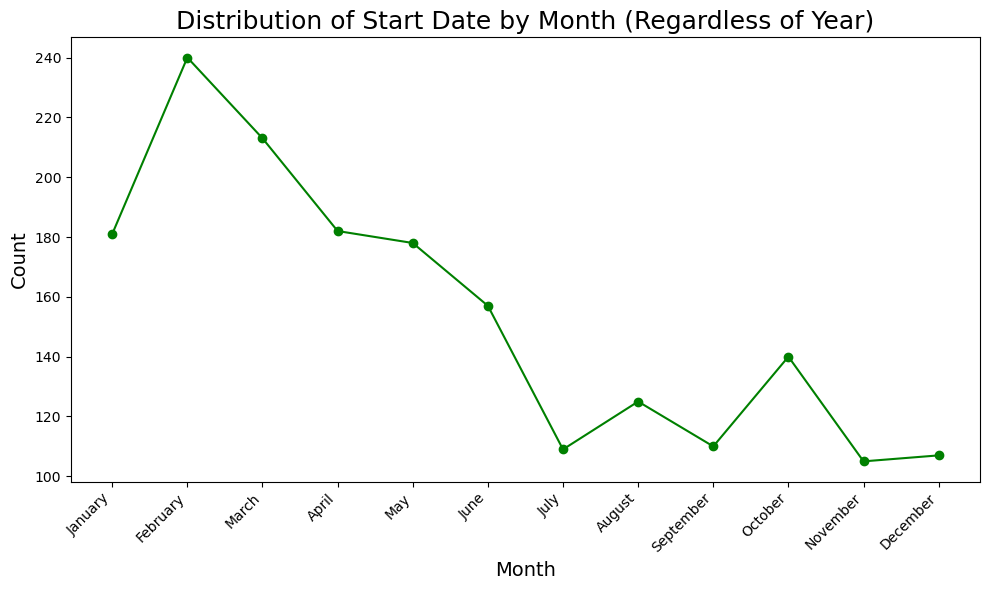

In [7]:
import pandas as pd
import matplotlib.pyplot as plt

# Ensure 'Start Date' is in datetime format
loaded_df['Start Date'] = pd.to_datetime(loaded_df['Start Date'], errors='coerce')

# Extract the month (ignoring the year)
loaded_df['Month'] = loaded_df['Start Date'].dt.month

# Count occurrences by month (aggregated across all years)
monthly_counts = loaded_df['Month'].value_counts().sort_index()

# Map month numbers to month names
months = pd.date_range('2023-01-01', periods=12, freq='M').strftime('%B')

# Plot the monthly distribution
plt.figure(figsize=(10, 6))
plt.plot(monthly_counts.index, monthly_counts.values, marker='o', color='green', linestyle='-')

# Add titles and labels
plt.title('Distribution of Start Date by Month (Regardless of Year)', fontsize=18)
plt.xlabel('Month', fontsize=14)
plt.ylabel('Count', fontsize=14)

# Customize x-axis to show month names
plt.xticks(monthly_counts.index, labels=months, rotation=45, ha='right')

# Tight layout for better spacing
plt.tight_layout()

# Show the plot
plt.show()


/var/folders/s3/s58q439926xb4bq1gzzpvw0r0000gn/T/ipykernel_32215/1943596691.py:14: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  months = pd.date_range('2023-01-01', periods=12, freq='M').strftime('%B')


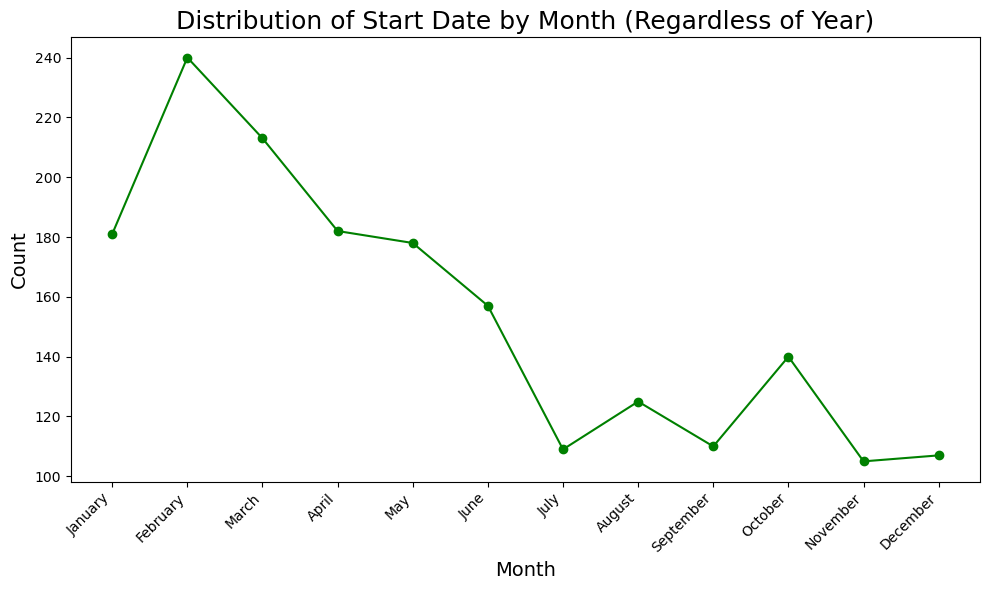

In [8]:
import pandas as pd
import matplotlib.pyplot as plt

# Ensure 'Start Date' is in datetime format
loaded_df['Start Date'] = pd.to_datetime(loaded_df['Start Date'], errors='coerce')

# Extract the month (ignoring the year)
loaded_df['Month'] = loaded_df['Start Date'].dt.month

# Count occurrences by month (aggregated across all years)
monthly_counts = loaded_df['Month'].value_counts().sort_index()

# Map month numbers to month names
months = pd.date_range('2023-01-01', periods=12, freq='M').strftime('%B')

# Plot the monthly distribution
plt.figure(figsize=(10, 6))
plt.plot(monthly_counts.index, monthly_counts.values, marker='o', color='green', linestyle='-')

# Add titles and labels
plt.title('Distribution of Start Date by Month (Regardless of Year)', fontsize=18)
plt.xlabel('Month', fontsize=14)
plt.ylabel('Count', fontsize=14)

# Customize x-axis to show month names
plt.xticks(monthly_counts.index, labels=months, rotation=45, ha='right')

# Tight layout for better spacing
plt.tight_layout()

# Show the plot
plt.show()


## Test plots

Cumulative histogram saved to: Output/cumulative_histogram_votes.png


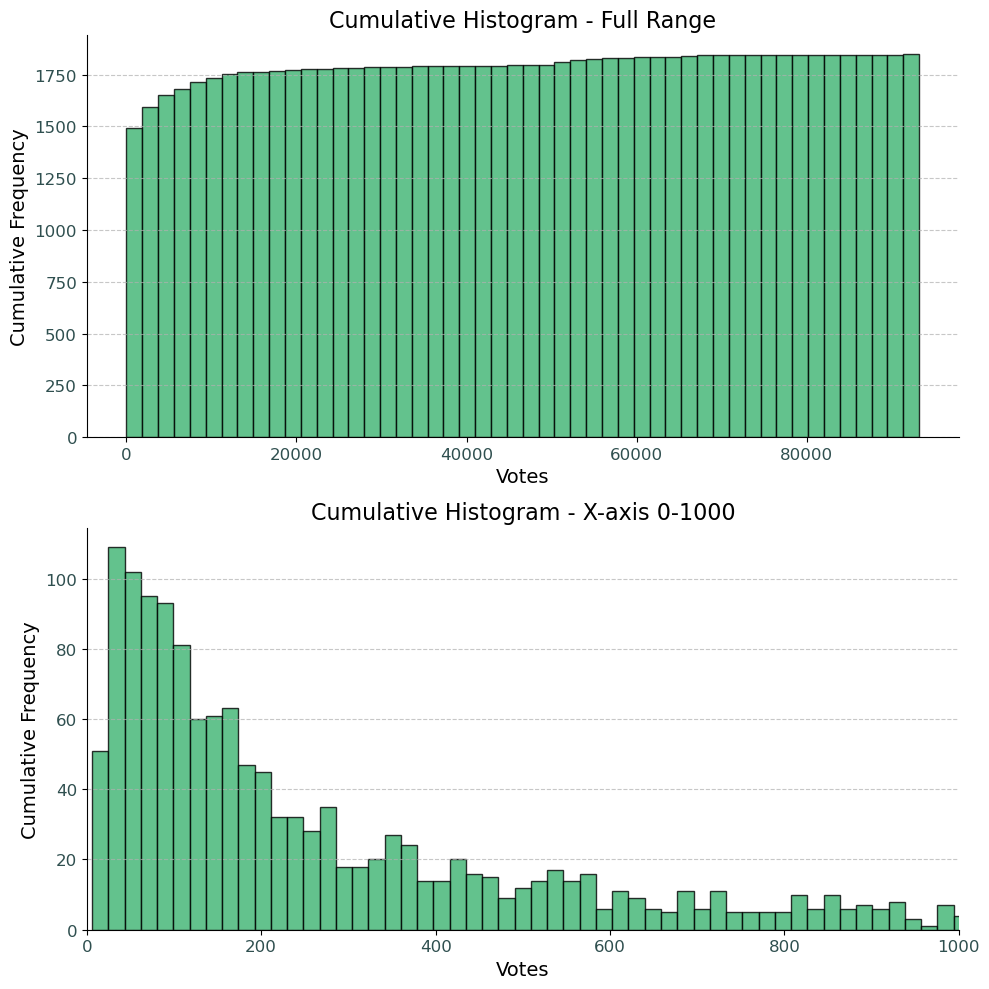

In [9]:
import os
import matplotlib.pyplot as plt

# Assuming 'loaded_df' is your DataFrame containing the 'Votes' column

# Define the output directory and file path
output_file_path = os.path.join(output_dir, "cumulative_histogram_votes.png")

# Create the figure with two subplots
plt.figure(figsize=(10, 10))

# Subplot 1: Full range cumulative histogram
plt.subplot(2, 1, 1)
plt.hist(loaded_df['Votes'], bins=50, cumulative=True, color='mediumseagreen', edgecolor='black', alpha=0.8)
plt.xlabel('Votes', fontsize=14)
plt.ylabel('Cumulative Frequency', fontsize=14)
plt.ylim(0, None)
plt.xticks(fontsize=12, color='darkslategray')
plt.yticks(fontsize=12, color='darkslategray')
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)
plt.gca().yaxis.grid(True, linestyle='--', alpha=0.7)
plt.title('Cumulative Histogram - Full Range', fontsize=16)

# Subplot 2: Cumulative histogram with x-axis limited to 0-1000
plt.subplot(2, 1, 2)
plt.hist(loaded_df['Votes'], bins=5000, color='mediumseagreen', edgecolor='black', alpha=0.8)
plt.xlabel('Votes', fontsize=14)
plt.ylabel('Cumulative Frequency', fontsize=14)
plt.ylim(0, None)
plt.xlim(0, 1000)  # Set x-axis limit to 0-1000
plt.xticks(fontsize=12, color='darkslategray')
plt.yticks(fontsize=12, color='darkslategray')
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)
plt.gca().yaxis.grid(True, linestyle='--', alpha=0.7)
plt.title('Cumulative Histogram - X-axis 0-1000', fontsize=16)

# Tight layout for better spacing
plt.tight_layout()

# Save the plot to the specified file path
plt.savefig(output_file_path)

# Confirm the file was created
print(f"Cumulative histogram saved to: {output_file_path}")
